# Project - 1 Handwritten Digits Identifier

Download the datasets using link,

(https://github.com/Coding-Lane/Neural-Network---MultiClass-Classifcation-with-Softmax/tree/main)

In [ ]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import random
from PIL import Image

In [ ]:
# Loading the datasets
X_train = np.loadtxt("/content/neural network project/train_X.csv", delimiter = ",").T
Y_train = np.loadtxt("/content/neural network project/train_label.csv", delimiter = ",").T
# The Y_train dataset is the hot representation of the labels
X_test = np.loadtxt("/content/neural network project/test_X.csv", delimiter = ",").T
Y_test = np.loadtxt("/content/neural network project/test_label.csv", delimiter = ",").T

In [ ]:
# Printing the shapes of the datasets
"""
There are '1000' images which is number of observations 'm', and '784 (28 x 28 pixels)' which is
number of features data 'n', without transpose the input shape is (1000, 784) i.e., (m,n) but
we want the input dataset shape to be as '(n,m)' not '(m,n)', so taking transpose of each dataset. """

print("Shape of X_train: ", X_train.shape)

"""
Y_train has '10' features data and '1000' observations,
this means '100' observations/images for '0', '100' for '1', '100' for '2', so on. """

print("Shape of Y_train: ", Y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of Y_test: ", Y_test.shape)

Shape of X_train:  (784, 1000)
Shape of Y_train:  (10, 1000)
Shape of X_test:  (784, 350)
Shape of Y_test:  (10, 350)


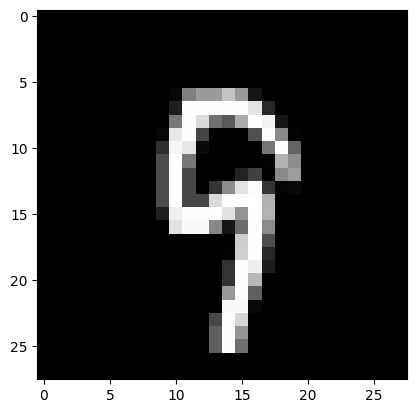

In [ ]:
# Displaying the image
index = random.randrange(0, X_train.shape[1])
plt.imshow(X_train[:, index].reshape(28,28), cmap = "gray")
plt.show()

Single Layered Neural Network

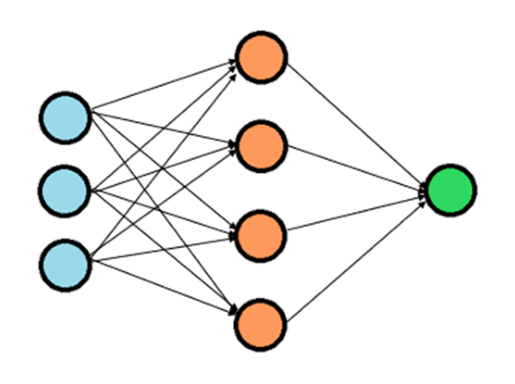

In [ ]:
# Neural network figure (Download link: )
img = Image.open('/content/neural network project/nn.png')
plt.imshow(img)
plt.axis('off')  # Hide the pixel grid axes
plt.show()

$\Large Step -1:The~parameters~are~initialized~randomly.$
<br><br>

$\Large Step-2: Forward~Propagation$
<br><br>
$Z_1 = W_1 * X + B_1$
<br><br>
$A_1 = f(Z_1) --> Hidden~Layer$
<br><br>
$Z_2 = W_2 * A_1 + B_2$
<br><br>
$A_2 = Softmax(Z_2) --> Output~Layer~~'Y'$
<br><br>
$\large Softmax,$ <br><br>
$$a_i = \frac{e^{z_i}}{\sum_{k=1}^{n} e^{z_k}}$$
<br><br>
$\Large Cost~Function,$ <br><br>
$$Loss = - \sum_{i=k}^{n}~[y_k*log(a_k)]$$
<br><br>
$$Cost = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{n}~[y_{ik}*log(a_{ik})]$$


$\Large Step-3: Back~Propagation$
<br>

$Starting~from~'dZ_2'~because~we~are~using~single~hidden~layer~neural~network.$
<br><br>
$dZ_2 = (A_2 - Y)$
<br><br>
$dW_2 = \frac{1}{m}.dZ_2.A^T_2$
<br><br>
$dB_2 = \frac{1}{m}.c.sum(dZ_2, 1)$
<br><br>
$dZ_1 = W_2^T.dZ_2*f_1'(Z_1)$
<br><br>
$dW_1 = \frac{1}{m}.dZ_1.A_1^T$
<br><br>
$dB_1 = \frac{1}{m}.c.sum(dZ_1,1)$
<br><br>

$\Large Step-4:~Updating~Parameters$
<br><br>
$W_2 = W_2 - \alpha * \frac{\partial Cost}{\partial W_2}$
<br><br>
$B_2 = B_2 - \alpha * \frac{\partial Cost}{\partial B_2}$
<br><br>
$W_1 = W_1 - \alpha * \frac{\partial Cost}{\partial W_1}$
<br><br>
$B_1 = B_1 - \alpha * \frac{\partial Cost}{\partial B_1}$
<br><br>

$\large Repeating~the~steps~2,3~and~4.$











# Initializing Functions For Activation Functions

In [ ]:
def tanh(x):
  return np.tanh(x)

def relu(x):
  return np.maximum(x,0) # Compares every number in the matrix with '0', if the number > 0 it remains same else becomes 0.

def softmax(x):
  expX = np.exp(x)
  return expX/np.sum(expX, axis = 0)

def derivative_tanh(x):
  # f'(z) = 1 - a^2
  return (1 - np.power(np.tanh(x), 2)) # Similar to 'np.tanh**2'.

def derivative_relu(x):
  return np.array(x > 0, dtype = np.float32) # Converting Boolean values to floating ones.





In [ ]:
# Practicing converting Boolean values to floating ones.

# a = np.array([[1,-3,0], [-4,-3,79]])
# np.array(a > 0, dtype = np.float32)

# Initializing Parameters

In [ ]:
# The no. of neurons in input layer, hidden layer, output layer is shown by n_x = 784, n_h = 1000, n_y = 10 respectively.
def initialize_parameters(n_x, n_h, n_y):
  w1 = np.random.randn(n_h,n_x)*0.01
  b1 = np.zeros((n_h, 1))

  w2 = np.random.randn(n_y,n_h)*0.01
  b2 = np.zeros((n_y, 1))

  parameters = {
    "w1":w1,
    "b1":b1,
    "w2":w2,
    "b2":b2
  }

  return parameters



In [ ]:
params = initialize_parameters(784, 1000, 10)
# print(X_train.shape) # (784, 1000)
# print(Y_train.shape) # (10, 1000)
# print(params["w1"].shape) # (1000, 784)
# print(params["w2"].shape) # (10, 1000)

z1 = np.dot(params["w1"], X_train) + params["b1"]
# print(z1.shape) # (1000, 1000)

a1 = relu(np.dot(params["w1"], X_train) + params["b1"])
# print(a1.shape) # (1000, 1000)

z2 = np.dot(params["w2"], a1) + params["b2"]
# print(z2.shape) # (10, 1000)

# print((np.sum(np.exp(z2), axis = 0)).shape) # (1, 1000) or (1000,)

a2 = softmax(z2)
# print(a2.shape) # (10, 1000)



# **1, WITH RELU ACTIVATION FUNCTION**

# Forward Propagation

In [ ]:
def forward_propagation_with_relu(x, parameters):

  w1 = parameters["w1"]
  b1 = parameters["b1"]
  w2 = parameters["w2"]
  b2 = parameters["b2"]

  z1 = np.dot(w1, x) + b1 # Z1 = W1 * X + B1 ('np.dot()' is matrix multiplication)
  a1 = relu(z1)

  z2 = np.dot(w2, a1) + b2 # Z2 = W2 * A1 + B2
  a2 = softmax(z2)

  forward_cache_relu = {
      "z1":z1,
      "a1":a1,
      "z2":z2,
      "a2":a2
  }

  return forward_cache_relu


# Cost Function

In [ ]:
def cost_function(a2, y):
  m = y.shape[1] # Number of observations
  cost = -(1/m)*np.sum(y*np.log(a2)) # Or we can write it as -(1/m) *np.sum(np.sum(y*np.log(a2, 0), 1)), in this, '0' is for row wise sum while '1' is for column wise sum.
  return cost

# Back Propagation

In [ ]:
def back_propagation_with_relu(x, y, parameters, forward_cache_relu):

  w1 = parameters["w1"]
  b1 = parameters["b1"]
  w2 = parameters["w2"]
  b2 = parameters["b2"]

  a1 = forward_cache_relu["a1"]
  a2 = forward_cache_relu["a2"]

  m = x.shape[1]

  dz2 = (a2 - y)
  dw2 = (1/m)*np.dot(dz2, a1.T)
  db2 = (1/m)*np.sum(dz2, axis = 1, keepdims = True) # 'axis = 1' shows column wise summation while 'keepdims = True' forces the 'np.sum()' to return a proper shape.

  dz1 = (1/m)*np.dot(w2.T, dz2)*derivative_relu(a1)
  dw1 = (1/m)*np.dot(dz1, x.T)
  db1 = (1/m)*np.sum(dz1, axis = 1, keepdims = True)

  gradients_relu = {
      "dw1":dw1,
      "db1":db1,
      "dw2":dw2,
      "db2":db2
  }

  return gradients_relu



In [ ]:
# # 'keepdims' demonstration
# a = np.array([[1,3,2], [4,2,4]])
# # Without 'keepdims'
# print("Without 'keepdims':\n", np.sum(a, axis = 1), "\nShape: ", np.sum(a, axis=1).shape)
# # With 'keepdims'
# print("With 'keepdims':\n", np.sum(a, axis = 1, keepdims = True), "\nShape: ", np.sum(a, axis=1, keepdims = True).shape)

In [ ]:
def update_parameters(parameters, gradients_relu, learning_rate):

  w1 = parameters["w1"]
  w2 = parameters["w2"]
  b1 = parameters["b1"]
  b2 = parameters["b2"]

  dw1 = gradients_relu["dw1"]
  db1 = gradients_relu["db1"]
  dw2 = gradients_relu["dw2"]
  db2 = gradients_relu["db2"]

  w1 = w1 - learning_rate*dw1
  b1 = b1 - learning_rate*db1
  w2 = w2 - learning_rate*dw2
  b2 = b2 - learning_rate*db2

  parameters = {
      "w1":w1,
      "b1":b1,
      "w2":w2,
      "b2":b2
  }

  return parameters


# Completing The Model

In [ ]:
def model_relu(x, y, n_h, learning_rate, iterations):
  n_x = x.shape[0]
  n_y = y.shape[0]

  cost_list = []

  parameters = initialize_parameters(n_x, n_h, n_y)

  for i in range(iterations):

    # Forward Propagation
    forward_cache_relu = forward_propagation_with_relu(x, parameters)

    # Calculating Error
    cost = cost_function(forward_cache_relu["a2"], y)

    # Backward Propagation
    gradients_relu = back_propagation_with_relu(x, y, parameters, forward_cache_relu)

    # Updating Parameters
    parameters = update_parameters(parameters, gradients_relu, learning_rate)

    # Storing the cost for every iterations
    cost_list.append(cost)

    # Printing cost after every 10 iterations
    if(i%(iterations/10) == 0):
      print("Cost after", i, "iterations is: ", cost)


  return parameters, cost_list


# Training The Model

In [ ]:
# Setting the number of iterations
iterations = 100

# Setting number of neurons in hidden layer & the learning rate
n_h = 1000
learning_rate = 0.002

# Calling the model and storing the returned values
Parameters, Cost_list = model_relu(X_train, Y_train, n_h = n_h, learning_rate = learning_rate, iterations = iterations)


Cost after 0 iterations is:  8.739340590251446
Cost after 10 iterations is:  30.013462634414267
Cost after 20 iterations is:  1.6561643576537226
Cost after 30 iterations is:  1.1799529645337035
Cost after 40 iterations is:  0.401392928567399
Cost after 50 iterations is:  0.17552764685871938
Cost after 60 iterations is:  0.17416587272249626
Cost after 70 iterations is:  0.83139756717518
Cost after 80 iterations is:  2.0573330587303618
Cost after 90 iterations is:  0.04936586521990995


# Plotting Cost Vs Iterations

<function matplotlib.pyplot.show(close=None, block=None)>

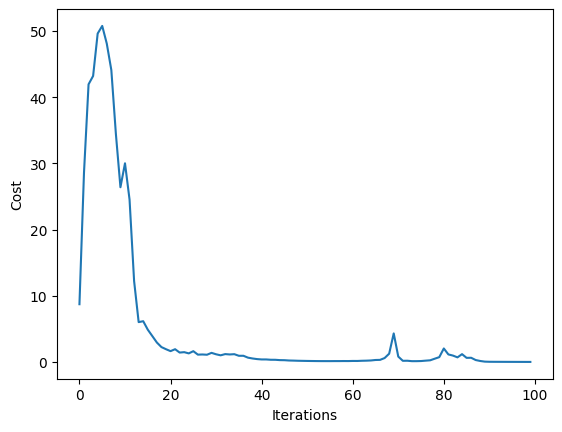

In [ ]:
# Creating list of evenly spaced numbers from 0 to 1000(exclusive)
t = np.arange(0, iterations)

# Plotting the points 'plot(x, y)'
plt.plot(t, Cost_list)

# Labeling 'x-axis'
plt.xlabel("Iterations")

# Labeling 'y-axis'
plt.ylabel("Cost")

# Showing the plot
plt.show

# Evaluating The Model

In [ ]:
def accuracy_relu(inp, labels, parameters):

  forward_cache_relu = forward_propagation_with_relu(inp, parameters)
  a_out = forward_cache_relu["a2"]

  # print(a_out)
  # 'a_out' returns the result in the form of probabilities, so we want the index number that has highest probability
  a_out = np.argmax(a_out, 0) # 'argmax()' reuturns the index number having highest probability, while '0' specify only in the row.
  # print(a_out) # (1, 1000) or (1000,)

  y_out = np.argmax(labels, 0)
  # print(y_out) # (1, 1000) or (1000,)

  # a_out == y_out # e.g., [False, False, False, True, False, False, ...]

  # When mean is applied to boolean values it turns it into 'True = 1' and 'False = 0'
  acc = np.mean(a_out == y_out)*100

  return acc

print("Acuracy On Train Data Using ReLU Funtion: ", accuracy_relu(X_train, Y_train, Parameters), "%")
print("Acuracy On Test Data Using ReLU Function: ", accuracy_relu(X_test, Y_test, Parameters), "%")


Acuracy On Train Data Using ReLU Funtion:  99.7 %
Acuracy On Test Data Using ReLU Function:  85.71428571428571 %


# Making A Predictive System

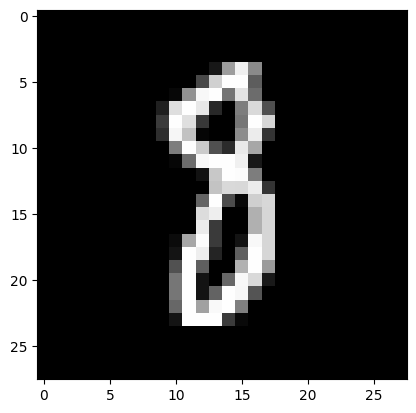


The Predicted The Number By The Model Using ReLU Function Is:   8


In [ ]:
# Displaying random image
index_relu = random.randrange(0, X_test.shape[1])
plt.imshow(X_test[:, index_relu].reshape(28,28), cmap = "gray")
plt.show()



# Making Prediction
forward_cache_relu = forward_propagation_with_relu(X_test[:, index_relu].reshape(X_test.shape[0], 1), Parameters)


# Before reshaping,
# print(X_test.shape) # (784, 350)

# After reshaping,
# print((X_test[:, index_relu].reshape(X_test.shape[0], 1))) # (784, 1)

# X_test[:, index_relu].reshape(X_test.shape[0], 1) # Putting each element in a seperate row, reshaping it to a matrix having 784 rows and 1 column.

a_out = forward_cache_relu["a2"]
a_out = np.argmax(a_out, 0)

print("\nThe Predicted The Number By The Model Using ReLU Function Is:  ", a_out[0])



# **2, WITH TANH ACTIVATION FUNCTION**




# Forward Propagation With Tanh Funtion

In [ ]:
def forward_propagation_with_tanh(x, parameters):

  w1 = parameters["w1"]
  b1 = parameters["b1"]
  w2 = parameters["w2"]
  b2 = parameters["b2"]

  z1 = np.dot(w1, x) + b1 # Z1 = W1 * X + B1 ('np.dot()' is matrix multiplication)
  a1 = tanh(z1)

  z2 = np.dot(w2, a1) + b2 # Z2 = W2 * A1 + B2
  a2 = softmax(z2)

  forward_cache_tanh = {
      "z1":z1,
      "a1":a1,
      "z2":z2,
      "a2":a2
  }

  return forward_cache_tanh


# Backward Propagation With Tanh Funtion

In [ ]:
def back_propagation_with_tanh(x, y, parameters, forward_cache_tanh):

  w1 = parameters["w1"]
  b1 = parameters["b1"]
  w2 = parameters["w2"]
  b2 = parameters["b2"]

  a1 = forward_cache_tanh["a1"]
  a2 = forward_cache_tanh["a2"]

  m = x.shape[1]

  dz2 = (a2 - y)
  dw2 = (1/m)*np.dot(dz2, a1.T)
  db2 = (1/m)*np.sum(dz2, axis = 1, keepdims = True) # 'axis = 1' shows column wise summation while 'keepdims = True' forces the 'np.sum()' to return a proper shape.

  dz1 = (1/m)*np.dot(w2.T, dz2)*derivative_tanh(a1)
  dw1 = (1/m)*np.dot(dz1, x.T)
  db1 = (1/m)*np.sum(dz1, axis = 1, keepdims = True)

  gradients_tanh = {
      "dw1":dw1,
      "db1":db1,
      "dw2":dw2,
      "db2":db2
  }

  return gradients_tanh



# Updating Parameters

In [ ]:
def update_parameters(parameters, gradients_tanh, learning_rate):

  w1 = parameters["w1"]
  w2 = parameters["w2"]
  b1 = parameters["b1"]
  b2 = parameters["b2"]

  dw1 = gradients_tanh["dw1"]
  db1 = gradients_tanh["db1"]
  dw2 = gradients_tanh["dw2"]
  db2 = gradients_tanh["db2"]

  w1 = w1 - learning_rate*dw1
  b1 = b1 - learning_rate*db1
  w2 = w2 - learning_rate*dw2
  b2 = b2 - learning_rate*db2

  parameters = {
      "w1":w1,
      "b1":b1,
      "w2":w2,
      "b2":b2
  }

  return parameters


# Completing The Model

In [ ]:
def model_tanh(x, y, n_h, learning_rate, iterations):
  n_x = x.shape[0]
  n_y = y.shape[0]

  cost_list = []

  parameters = initialize_parameters(n_x, n_h, n_y)

  for i in range(iterations):

    # Forward Propagation
    forward_cache_tanh = forward_propagation_with_tanh(x, parameters)

    # Calculating Error
    cost = cost_function(forward_cache_tanh["a2"], y)

    # Backward Propagation
    gradients_tanh = back_propagation_with_tanh(x, y, parameters, forward_cache_tanh)

    # Updating Parameters
    parameters = update_parameters(parameters, gradients_tanh, learning_rate)

    # Storing the cost for every iterations
    cost_list.append(cost)

    # Printing cost after every 10 iterations
    if(i%(iterations/10) == 0):
      print("Cost after", i, "iterations is: ", cost)


  return parameters, cost_list


# Training The Model

In [ ]:
# Setting the number of iterations
iterations = 500

# Setting number of neurons in hidden layer & the learning rate
n_h = 1000
learning_rate = 0.03

# Calling the model and storing the returned values
Parameters, Cost_list = model_tanh(X_train, Y_train, n_h = n_h, learning_rate = learning_rate, iterations = iterations)


Cost after 0 iterations is:  2.344296937655312
Cost after 50 iterations is:  0.37725362408195307
Cost after 100 iterations is:  0.23206409430796077
Cost after 150 iterations is:  0.16343789018187943
Cost after 200 iterations is:  0.12271114333843858
Cost after 250 iterations is:  0.09634219568136727
Cost after 300 iterations is:  0.0783576170213907
Cost after 350 iterations is:  0.06554895605728192
Cost after 400 iterations is:  0.056068838796684034
Cost after 450 iterations is:  0.04881903001225844


# Plotting Cost Vs Iterations

<function matplotlib.pyplot.show(close=None, block=None)>

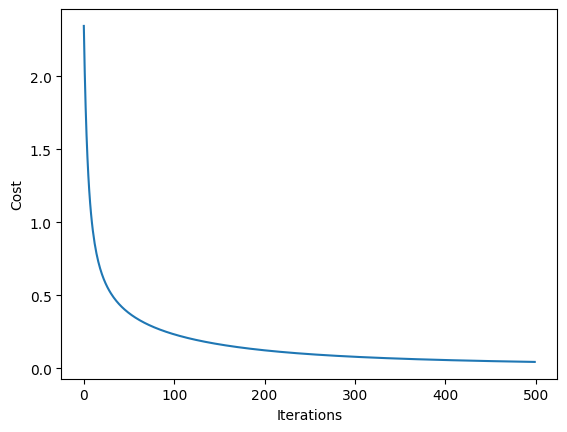

In [ ]:
# Creating list of evenly spaced numbers from 0 to 1000(exclusive)
t = np.arange(0, iterations)

# Plotting the points 'plot(x, y)'
plt.plot(t, Cost_list)

# Labeling 'x-axis'
plt.xlabel("Iterations")

# Labeling 'y-axis'
plt.ylabel("Cost")

# Showing the plot
plt.show

# Evaluating The Model

In [ ]:
def accuracy_tanh(inp, labels, parameters):

  forward_cache_tanh = forward_propagation_with_tanh(inp, parameters)
  a_out = forward_cache_tanh["a2"]

  # print(a_out)
  # 'a_out' returns the result in the form of probabilities, so we want the index number that has highest probability
  a_out = np.argmax(a_out, 0) # 'argmax()' reuturns the index number having highest probability, while '0' specify only in the row.

  # print(a_out)

  y_out = np.argmax(labels, 0)
  # print(y_out)

  # a_out == y_out # e.g., [False, False, False, True, False, False, ...]

  # When mean is applied to boolean values it turns it into 'True = 1' and 'False = 0'
  acc = np.mean(a_out == y_out)*100

  return acc

print("Acuracy On Train Data Using Tanh Funtion: ", accuracy_tanh(X_train, Y_train, Parameters), "%")
print("Acuracy On Test Data Using Tanh Function: ", accuracy_tanh(X_test, Y_test, Parameters), "%")

# print((np.argmax(a2, 0))) # (1, 1000) or (1000,)

# print((np.argmax(Y_train, 0))) # (1, 1000) or (1000,)


Acuracy On Train Data Using Tanh Funtion:  100.0 %
Acuracy On Test Data Using Tanh Function:  86.57142857142858 %


# Making A Predictive System

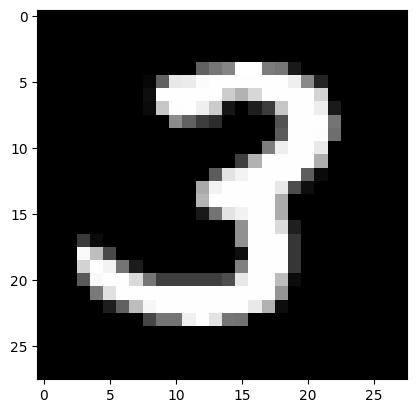


The Predicted The Number By The Model Using Tanh Function Is:   3


In [ ]:
# Displaying random image
index_tanh = random.randrange(0, X_test.shape[1])
plt.imshow(X_test[:, index_tanh].reshape(28,28), cmap = "gray")
plt.show()



# Making Prediction
forward_cache_tanh = forward_propagation_with_tanh(X_test[:, index_tanh].reshape(X_test.shape[0], 1), Parameters)


# Before reshaping,
# print(X_test.shape) # (784, 350)

# After reshaping,
# print((X_test[:, index_tanh].reshape(X_test.shape[0], 1))) # (784, 1)

# X_test[:, index_tanh].reshape(X_test.shape[0], 1) # Putting each element in a seperate row, reshaping it to a matrix having 784 rows and 1 column.

a_out = forward_cache_tanh["a2"]
a_out = np.argmax(a_out, 0)

print("\nThe Predicted The Number By The Model Using Tanh Function Is:  ", a_out[0])

